## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 13. 환율 노출도(수출비중 × 환율 변화) EDA

## 목적
D7 결정(2026-10-01): 환율을 통제변수로 **포함**하기로 했다. 이 노트북은 모형 결과를 보기 전에 **변수를 만들고, 만든 변수가 쓸 만한지** 점검하는 EDA다.

`FX_it = 수출비중_i × Δln(원/달러 연평균 환율)_t`

- 수출비중_i: 업종 i가 만든 상품 중 수출이 유발한 생산의 비율(2019년 산업연관표, 업종 고정값)
- Δln(환율)_t: 원/달러 연평균의 전년 대비 로그 변화율(×100)

## 왜 곱 형태인가
환율 변화 자체는 40개 업종이 같은 해에 똑같이 겪어 연도 고정효과에 완전히 흡수된다. 업종마다 다른 수출비중을 곱해야 업종별로 값이 달라진다(원자재 충격·반도체 통제와 같은 논리).

## 확인할 것
1. 수출비중 계산이 타당한가(업종 순서, 정의 간 일치)
2. 수출비중이 노출도·현금여력과 얼마나 겹치는가(핵심 질문)
3. 고정효과를 뺀 뒤에도 변수에 정보가 남는가
4. 다른 통제변수(원자재 충격, 반도체)와 겹치지 않는가

## 주의
- 이 노트북은 FX를 넣은 **회귀 결과(β)를 보지 않는다.** 변수 점검만 한다.
- 수출비중은 2019년 한 해 구조로 고정한 값이며, 헤지·가격전가는 반영하지 못한다(Bartram 외 2010 초록: 기업은 환율 변화를 일부 전가하고 영업·금융 헤지를 사용).
- 반도체 겹침 점검에 쓰는 `반도체 더미 × 출하 증가율`은 **D3 미결정 상태에서의 예시**일 뿐이며 A안을 선택했다는 뜻이 아니다.

In [2]:
import numpy as np, pandas as pd, openpyxl, statsmodels.api as sm
import matplotlib as mpl, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False); mpl.rcParams["font.family"] = f; break
    except Exception: pass
mpl.rcParams["axes.unicode_minus"] = False

DATA = str(RAW)
PANEL = str(PROCESSED) + "/"
W = pd.read_csv(str(INTERIM / "가중치행렬_W_2019_계산용.csv"), encoding="utf-8-sig", index_col=0)
W.columns = [str(c).zfill(4) for c in W.columns]
print("W 행렬:", W.shape, "| 행합 최소·최대:", round(float(W.sum(axis=1).min()), 6), round(float(W.sum(axis=1).max()), 6))

W 행렬: (40, 381) | 행합 최소·최대: 1.0 1.0


## 1. 상품별 수출 유발 비중 → 40개 업종 수출비중

**한 내용**: 투입산출표 "최종수요항목별 생산유발액" 시트에서 상품별로 수출(9140)이 유발한 생산액을 최종수요계(9190=총산출)로 나눠 **수출유발비중**을 만든다. 이를 40×381 가중평균 행렬 W(산출액 가중, 행합 1)로 40개 업종에 집계한다.

**비교 정의**: 직접 수출비중 = 총거래표의 상품별 수출(9140) ÷ 총산출. 수출유발비중은 수출품 생산에 투입된 중간재(예: 수출 자동차에 들어간 철강)의 간접 수출까지 포함하고, 직접 비중은 그 상품이 직접 수출된 몫만 센다.

In [3]:
wb = openpyxl.load_workbook(f"{DATA}/원자재/투입산출표_생산자가격_기본부문_2019년연장표.xlsx", read_only=True, data_only=True)

# (a) 수출유발비중 = 수출유발액(9140) / 최종수요계(9190)
rows = list(wb["최종수요항목별 생산유발액"].iter_rows(values_only=True))[6:]
ind = {str(r[0]).strip(): (float(r[8]), float(r[9])) for r in rows
       if r[0] is not None and str(r[0]).strip() in W.columns}
ratio = (pd.Series({c: v[0] for c, v in ind.items()}) / pd.Series({c: v[1] for c, v in ind.items()})).reindex(W.columns)
zero = ratio[ratio.isna()].index.tolist()
print("총산출이 0이라 비중을 못 만드는 상품코드:", zero, "| W 가중치 최대:", W[zero].max().max())

# (b) 직접 수출비중 = 총거래표 수출(9140) / 총산출
R = list(wb["A표_총거래표(생산자)"].iter_rows(values_only=True))
hdr, names = R[4], R[5]
j_exp = [i for i, x in enumerate(hdr) if str(x).strip() == "9140"][0]
j_out = [i for i, x in enumerate(names) if x and "총산출" in str(x)][0]
direct = {}
for r in R[6:]:
    c = str(r[0]).strip() if r[0] is not None else ""
    if c in W.columns and r[j_exp] is not None and r[j_out]:
        direct[c] = r[j_exp] / r[j_out]
direct = pd.Series(direct).reindex(W.columns)

share = (W @ ratio.fillna(0))          # 0~1, 수출유발 기준(주 정의)
share_dir = (W @ direct.fillna(0))     # 0~1, 직접 수출 기준(비교)
names40 = pd.read_csv(PANEL + "재무_원자재_병합패널.csv", encoding="utf-8-sig").drop_duplicates("업종코드").set_index("업종코드")["업종"]
tab = pd.DataFrame({"업종": names40, "수출유발비중(%)": share * 100, "직접수출비중(%)": share_dir * 100}).round(1)
print("상위 10"); print(tab.sort_values("수출유발비중(%)", ascending=False).head(10).to_string())
print("\n하위 8"); print(tab.sort_values("수출유발비중(%)").head(8).to_string())
print("\n두 정의의 상관: Pearson %.2f, Spearman %.2f" % (tab.iloc[:,1].corr(tab.iloc[:,2]), tab.iloc[:,1].corr(tab.iloc[:,2], method="spearman")))
print(tab["수출유발비중(%)"].describe().round(1).to_dict())

총산출이 0이라 비중을 못 만드는 상품코드: ['0194', '0612', '0841'] | W 가중치 최대: 0


상위 10
            업종  수출유발비중(%)  직접수출비중(%)
I3102      반도체       95.6       87.2
I3312       조선       82.3       76.8
I3103    디스플레이       79.5       47.0
I3201     석유화학       78.9       48.9
I3203  기타 전자부품       74.4       37.6
I3104      컴퓨터       71.1       67.3
I3309     비철금속       69.4       35.5
I3108       전지       68.2       41.3
I3304       유리       63.0       29.1
I3302       고무       62.5       37.1

하위 8
            업종  수출유발비중(%)  직접수출비중(%)
I3306      시멘트        4.1        1.8
I3402       담배       12.0       11.7
I3209  기타 수송장비       12.5       10.3
I3401      음식료       13.6        5.9
I3409       가구       14.6        8.8
I3406       목재       15.1        0.9
I3101       의약       20.7       17.7
I3208       철도       23.5       16.4

두 정의의 상관: Pearson 0.82, Spearman 0.78
{'count': 40.0, 'mean': 47.9, 'std': 22.2, 'min': 4.1, '25%': 34.2, '50%': 51.2, '75%': 62.4, 'max': 95.6}


**결과·해석**
- 총산출이 0인 상품 3개(0194, 0612, 0841)는 W에서 가중치가 0이라 집계에 영향이 없다.
- 상위는 반도체(95.6%)·조선(82.3%)·디스플레이·석유화학·기타 전자부품·컴퓨터이고, 하위는 시멘트(4.1%)·담배·기타 수송장비·음식료·가구로 **상식과 부합**한다.
- 두 정의는 순위상 상관이 0.78로 방향은 같다. 수출유발비중이 석유화학·유리·고무 같은 **중간재 업종에서 직접 비중보다 훨씬 크다**(수출품에 들어가는 몫까지 잡기 때문). 어느 정의가 맞는지는 "환율이 업종 수익에 미치는 경로"를 어떻게 보느냐에 달렸고, 아래에서는 수출유발 기준을 주 정의로 쓴다.
- 2019년 구조로 고정한 값이므로 업종의 시간 변화는 반영하지 못한다.

## 2. 환율 변화율 Δln(환율)

**한 내용**: 원/달러 연평균 환율에서 전년 대비 로그 변화율(×100)을 만든다. 긴축기 패널(2018~2023)은 2017년, 평시 패널(2015~2019)은 2014년 값이 필요하다.

In [4]:
fx = pd.read_csv(f"{DATA}/환율/원달러_환율_연평균_1990_2025.csv", encoding="utf-8-sig")
fx.columns = ["year", "fx"]; fx["fx"] = fx.fx.astype(str).str.replace(",", "").astype(float)
fx = fx.set_index("year").fx
dln = np.log(fx).diff() * 100
print(pd.DataFrame({"연평균(원/달러)": fx, "Δln×100": dln.round(2)}).loc[2014:2023].T.to_string())

year          2014     2015     2016     2017     2018     2019     2020     2021     2022     2023
연평균(원/달러)  1053.12  1131.52  1160.41  1130.48  1100.58  1166.11  1180.01  1144.61  1292.20  1305.93
Δln×100      -3.90     7.18     2.52    -2.61    -2.68     5.78     1.18    -3.05    12.13     1.06


**결과·해석**: 2022년이 +12.13로 압도적으로 크고 나머지 해는 -3.05~+7.18이다. 긴축기 패널에서 FX 변수의 시간 변동은 사실상 **2022년 한 해**가 만든다(Post와 겹치는 해). 이것이 긴축 효과와 환율 효과를 분리하기 어렵게 만드는 부분이다.

## 3. 패널에 붙이기

`FX_it = 수출비중_i(0~1) × Δln(환율)_t(×100)`. 긴축기·평시 병합패널에 `fx` 열을 만들고 결측이 없는지 확인한다.

In [5]:
def load(f):
    d = pd.read_csv(PANEL + f, encoding="utf-8-sig").rename(columns={
        "사전노출도(%)": "exp", "사전현금여력(%)": "cash", "Post×사전노출도": "px", "Post×사전현금여력": "pc",
        "업종코드": "code", "연도": "year", "shock_baseline_1111only": "shock"})
    d["share"] = d.code.map(share); d["dln"] = d.year.map(dln); d["fx"] = d.share * d.dln
    return d
tight = load("재무_원자재_병합패널.csv"); calm = load("평시_재무_원자재_병합패널.csv")
for nm, d in [("긴축기", tight), ("평시", calm)]:
    print(f"{nm}: {d.shape}, fx 결측 {d.fx.isna().sum()}, 범위 {d.fx.min():.1f} ~ {d.fx.max():.1f}")
print(tight[tight.업종.isin(["반도체", "주조", "시멘트"])].pivot_table(index="업종", columns="year", values="fx").round(1))

긴축기: (240, 19), fx 결측 0, 범위 -2.9 ~ 11.6
평시: (200, 19), fx 결측 0, 범위 -2.6 ~ 6.9
year  2018  2019  2020  2021  2022  2023
업종                                      
반도체   -2.6   5.5   1.1  -2.9  11.6   1.0
시멘트   -0.1   0.2   0.0  -0.1   0.5   0.0
주조    -1.5   3.2   0.6  -1.7   6.6   0.6


**결과·해석**: 두 패널 모두 결측 없이 붙었다. 수출비중이 큰 반도체는 2022년에 12.13×0.956≈11.6으로 가장 크고, 시멘트는 거의 0이다.

## 4. 핵심 질문: 수출비중이 노출도·현금여력과 겹치는가

**한 내용**: 업종 단위(40개)에서 수출비중과 사전노출도·사전현금여력의 상관을 본다. 많이 겹치면 환율을 넣은 모형에서 노출도 계수가 환율과 섞일 수 있다.

[긴축기] 수출비중~노출도 Pearson -0.26 / Spearman -0.28 | 수출비중~현금여력 Pearson 0.22 / Spearman 0.24
   반도체5 평균 수출비중 74% vs 나머지 44%
[평시] 수출비중~노출도 Pearson -0.23 / Spearman -0.25 | 수출비중~현금여력 Pearson 0.15 / Spearman 0.13
   반도체5 평균 수출비중 74% vs 나머지 44%


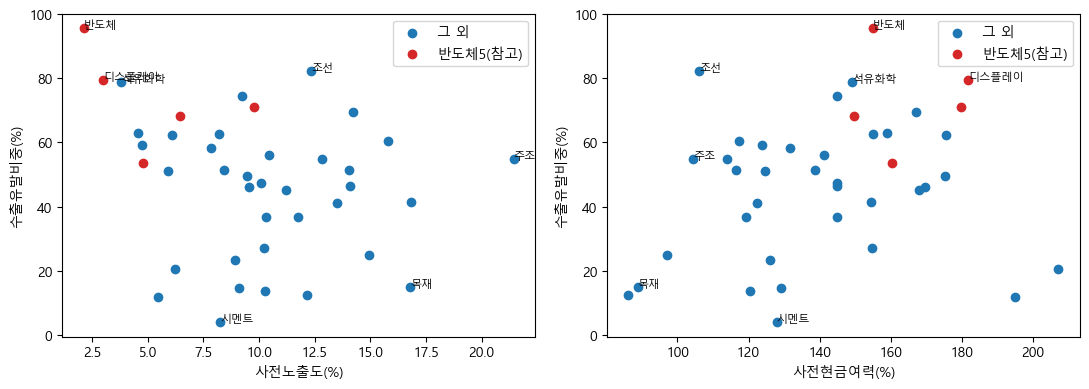

In [6]:
semi5 = ["I3102", "I3103", "I3104", "I3105", "I3108"]   # 11번 노트북의 반도체5(사후 선정 그룹, 참고용)
for nm, d in [("긴축기", tight), ("평시", calm)]:
    u = d.drop_duplicates("code")
    print(f"[{nm}] 수출비중~노출도 Pearson {u.share.corr(u.exp):.2f} / Spearman {u.share.corr(u.exp, method='spearman'):.2f} | "
          f"수출비중~현금여력 Pearson {u.share.corr(u['cash']):.2f} / Spearman {u.share.corr(u['cash'], method='spearman'):.2f}")
    print(f"   반도체5 평균 수출비중 {u[u.code.isin(semi5)].share.mean()*100:.0f}% vs 나머지 {u[~u.code.isin(semi5)].share.mean()*100:.0f}%")

u = tight.drop_duplicates("code")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (x, lab) in zip(ax, [("exp", "사전노출도(%)"), ("cash", "사전현금여력(%)")]):
    m = u.code.isin(semi5)
    a.scatter(u[x][~m], u.share[~m]*100, c="tab:blue", label="그 외")
    a.scatter(u[x][m], u.share[m]*100, c="tab:red", label="반도체5(참고)")
    for _, r in u.iterrows():
        if r.share > .75 or r.업종 in ["시멘트", "주조", "목재"]: a.annotate(r.업종, (r[x], r.share*100), fontsize=8)
    a.set_xlabel(lab); a.set_ylabel("수출유발비중(%)"); a.legend()
plt.tight_layout(); plt.show()

**결과·해석**
- 긴축기 기준 수출비중과 노출도의 상관은 -0.26(Spearman -0.28), 현금여력과는 +0.22이다. **약~중간 수준**이고, 평시도 -0.23/+0.15로 비슷하다. 10번 노트북이 "완전히 겹치는 수준"으로 쓴 관행적 기준(|r|≥0.7, 공식 기준 아님)에는 못 미친다.
- 방향은 "수출이 큰 업종일수록 단기 빚 비중이 낮고 현금여력이 크다"로, 반도체5의 평균 수출비중(74%)이 나머지(44%)보다 훨씬 높은 것과 이어진다. 즉 **환율 변수가 반도체 계열 효과와 부분적으로 겹칠 수 있다**(7절에서 확인).
- 40개 업종에서의 상관이라 불확실성이 크다. 이 값은 겹침 정도의 대략적 확인이다.

## 5. 고정효과를 뺀 뒤에도 정보가 남는가, 다른 통제변수와 겹치는가

**한 내용**: FX는 수출비중(업종 고정) × 환율 변화(연도 공통) 형태라 업종·연도 고정효과를 뺀 뒤 남는 변동이 얼마인지 확인한다. 이어서 업종·연도 평균을 제거한 변수들(px, pc, shock, fx)로 상관과 VIF를 계산한다.

In [7]:
def within(d, cols):
    w = d.copy()
    for k in cols:
        w[k] = d[k] - d.groupby("code")[k].transform("mean") - d.groupby("year")[k].transform("mean") + d[k].mean()
    return w

def vif(df, cols):
    out = {}
    for k in cols:
        oth = [x for x in cols if x != k]
        r2 = sm.OLS(df[k], sm.add_constant(df[oth])).fit().rsquared
        out[k] = round(1/(1-r2), 2)
    return out

cols = ["px", "pc", "shock", "fx"]
for nm, d in [("긴축기", tight), ("평시", calm)]:
    w = within(d, cols)
    print(f"[{nm}] fx 분산: 원값 {d.fx.var():.1f} → 고정효과 제거 후 {w.fx.var():.1f} ({w.fx.var()/d.fx.var():.0%} 남음)")
    print(w[cols].corr().round(2).to_string())
    print("   VIF(고정효과 제거 후):", vif(w, cols), "\n")

[긴축기] fx 분산: 원값 7.9 → 고정효과 제거 후 1.3 (17% 남음)
         px    pc  shock    fx
px     1.00 -0.53  -0.05 -0.15
pc    -0.53  1.00  -0.01  0.13
shock -0.05 -0.01   1.00  0.01
fx    -0.15  0.13   0.01  1.00
   VIF(고정효과 제거 후): {'px': np.float64(1.42), 'pc': np.float64(1.41), 'shock': np.float64(1.0), 'fx': np.float64(1.03)} 

[평시] fx 분산: 원값 4.9 → 고정효과 제거 후 0.8 (17% 남음)
         px    pc  shock    fx
px     1.00 -0.63  -0.12  0.02
pc    -0.63  1.00   0.02 -0.01
shock -0.12  0.02   1.00 -0.11
fx     0.02 -0.01  -0.11  1.00
   VIF(고정효과 제거 후): {'px': np.float64(1.7), 'pc': np.float64(1.67), 'shock': np.float64(1.03), 'fx': np.float64(1.01)} 



**결과·해석**
- 고정효과를 뺀 뒤에도 FX 분산의 약 17%가 남는다. FX는 사라지지 않지만 **정보량이 크지 않다**(연도 공통 부분이 대부분).
- 고정효과 제거 후 FX와 px·pc의 상관은 긴축기 -0.15·+0.13, 평시 +0.02·-0.01로 작고, VIF는 모두 1.0~1.7로 **다중공선성 문제는 없다.**
- 즉 겹침 면에서는 FX를 넣어도 기존 변수들의 계수를 불안정하게 만들 이유가 없다.

## 6. 반도체 통제와의 겹침 (D3 미결정 상태의 점검)

**한 내용**: 반도체 통제의 한 후보(예시)인 `반도체5 더미 × 출하 증가율(%)`을 만들어, 환율 변수와 얼마나 겹치는지 본다. 반도체5의 수출비중이 크기 때문에 두 변수가 같은 업종·시기 패턴을 공유할 수 있다.

**주의**: 이는 후보 A를 선택한다는 뜻이 아니라 겹침 정도만 보는 점검이다.

In [8]:
ws = openpyxl.load_workbook(f"{DATA}/반도체/ISTANS_반도체_20260926214520.xlsx", data_only=True).worksheets[0]
R2 = list(ws.iter_rows(values_only=True))
yrs = [int(str(h).split()[-1]) for h in R2[0][2:]]
ship = pd.Series([float(x) for x in R2[2][2:]], index=yrs)       # 출하지수(2020=100)
g = ship.pct_change() * 100
print("출하 증가율(%):", g.loc[2018:2023].round(1).to_dict())

for nm, d in [("긴축기", tight), ("평시", calm)]:
    d["semi"] = d.code.isin(semi5).astype(int) * d.year.map(g)
    cols2 = ["px", "pc", "shock", "fx", "semi"]
    w = within(d, cols2)
    print(f"[{nm}] fx~semi 상관(고정효과 제거 후) {w.fx.corr(w.semi):.2f} | VIF:", vif(w, cols2))

출하 증가율(%): {2018: 18.6, 2019: 11.8, 2020: 27.6, 2021: 22.7, 2022: 2.9, 2023: 8.9}
[긴축기] fx~semi 상관(고정효과 제거 후) -0.33 | VIF: {'px': np.float64(1.5), 'pc': np.float64(1.41), 'shock': np.float64(1.01), 'fx': np.float64(1.12), 'semi': np.float64(1.25)}
[평시] fx~semi 상관(고정효과 제거 후) 0.09 | VIF: {'px': np.float64(1.7), 'pc': np.float64(1.67), 'shock': np.float64(1.04), 'fx': np.float64(1.02), 'semi': np.float64(1.02)}


**결과·해석**
- 긴축기에서 FX와 반도체 후보의 상관은 -0.33이고, 두 변수를 함께 넣어도 VIF는 최대 1.5로 낮다. 평시에는 상관 0.09로 거의 겹치지 않는다.
- **구조적으로는 겹치는 부분이 있다**(반도체5의 수출비중 74%, 2022년 환율 급등과 반도체 하락이 같은 해). 다만 통계적 공선성은 작아서, 두 변수를 함께 넣어도 계수를 분리 못 할 정도는 아니다.
- 반도체 통제 방식(D3)을 정한 뒤 이 점검을 같은 방식으로 다시 하면 된다.

## 7. 기술통계 수준의 ICR과의 관계 (참고)

**한 내용**: 10번 노트북이 변수들과 ICR의 상관을 본 것과 같은 목적의 참고용 확인이다. **회귀 결과가 아니다.**

In [9]:
for nm, d in [("긴축기", tight), ("평시", calm)]:
    w = within(d, ["fx", "ICR"])
    print(f"[{nm}] corr(fx, ICR) 원값 {d.fx.corr(d.ICR):.3f} | 고정효과 제거 후 {w.fx.corr(w.ICR):.3f}")

[긴축기] corr(fx, ICR) 원값 -0.088 | 고정효과 제거 후 -0.170
[평시] corr(fx, ICR) 원값 -0.088 | 고정효과 제거 후 -0.220


**결과·해석**: 원값 상관은 -0.09, 고정효과 제거 후 긴축기 -0.17·평시 -0.22로 약하다. 상관만으로 환율 효과의 방향이나 크기를 결론 내릴 수 없다. 이 값을 보고 변수 정의를 바꾸지 않는다.

## 8. 정리

| 점검 | 결과 |
|---|---|
| 수출비중 계산 | 381개 상품 모두 대응, 3개 상품은 총산출 0(영향 없음), 상식과 부합, 직접 비중과 순위 상관 0.78 |
| 노출도·현금여력과 겹침 | 약~중간(-0.26 / +0.22), 반도체5와 방향이 이어짐 |
| 고정효과 후 정보 | 분산의 약 17% 남음, 시간 변동은 사실상 2022년이 만듦 |
| 다중공선성 | VIF 1.0~1.7로 문제 없음 |
| 반도체 후보와 겹침 | 긴축기 상관 -0.33, VIF ≤1.5 (D3 결정 후 재확인) |

**한계**: 수출비중은 2019년 단일 연도 구조로 고정, 직접·유발 정의 선택이 결과에 영향 줄 수 있음(강건성으로 다룰 후보), 헤지·가격전가 미반영, 환율 효과와 긴축 효과가 2022년 한 해에 몰려 분리 어려움, 수입 원자재 비용 경로는 원자재 충격 지표가 일부 다룸.

**다음**: D3·D4 결정 후 FX를 포함한 모형으로 본분석, 수출유발 vs 직접 정의 강건성.